# 05 — Support Vector Machine (SVM)

**O que é:** algoritmo que encontra o hiperplano de margem máxima que separa as classes no espaço de features.

**Kernel RBF (Radial Basis Function):** transforma os dados em espaço de alta dimensão para tornar separáveis casos não-lineares.

**Vantagens:** eficiente em espaços de alta dimensão, robusto quando número de features > amostras.

**Desvantagens:** lento para grandes datasets, difícil de interpretar, sensível à escala (por isso normalizamos os dados).

## Carregamento e Preparação (igual aos notebooks anteriores)

In [1]:
import pandas as pd
import numpy as np
import os
import joblib
from IPython.display import Image, display
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc
)

FEATURES = ['Plantel', 'Estrangeiros', 'Valor de Mercado Total']
TARGET   = 'Status_bin'

df = pd.read_excel(os.path.join('..', 'dados', 'BASE_FINAL.xlsx'), sheet_name='CLUBES')
df.columns = df.columns.str.strip()
df[TARGET] = df['Situacao'].apply(lambda x: 0 if str(x).strip().lower() == 'rebaixado' else 1)

df_rot = df[df['Temporada'] < 2025].copy()
df_tr  = df_rot[df_rot['Temporada'] <= 2022]
df_te  = df_rot[df_rot['Temporada']  > 2022]

scaler = StandardScaler()
X_tr = scaler.fit_transform(df_tr[FEATURES])
y_tr = df_tr[TARGET].values
X_te = scaler.transform(df_te[FEATURES])
y_te = df_te[TARGET].values

print(f'Treino: {X_tr.shape} | Teste: {X_te.shape}')

Treino: (180, 3) | Teste: (40, 3)


## Treinamento do SVM

Usamos kernel RBF (padrão), `class_weight='balanced'` e `probability=True` para obter probabilidades.

In [2]:
svm    = joblib.load(os.path.join('..', 'modelos', 'svm.pkl'))
print('Modelo carregado: SVM')
print(f'Kernel: {svm.kernel} | C: {svm.C} | Gamma: {svm.gamma}')
print(f'Vetores de suporte: {svm.n_support_}  (por classe)')

Modelo carregado: SVM
Kernel: rbf | C: 1.0 | Gamma: scale
Vetores de suporte: [24 89]  (por classe)


## Avaliação no Conjunto de Teste

Acurácia no teste: 0.7750 (77.50%)

Relatório de Classificação:
              precision    recall  f1-score   support

   Rebaixado       0.33      0.12      0.18         8
  Permaneceu       0.81      0.94      0.87        32

    accuracy                           0.78        40
   macro avg       0.57      0.53      0.53        40
weighted avg       0.72      0.78      0.73        40



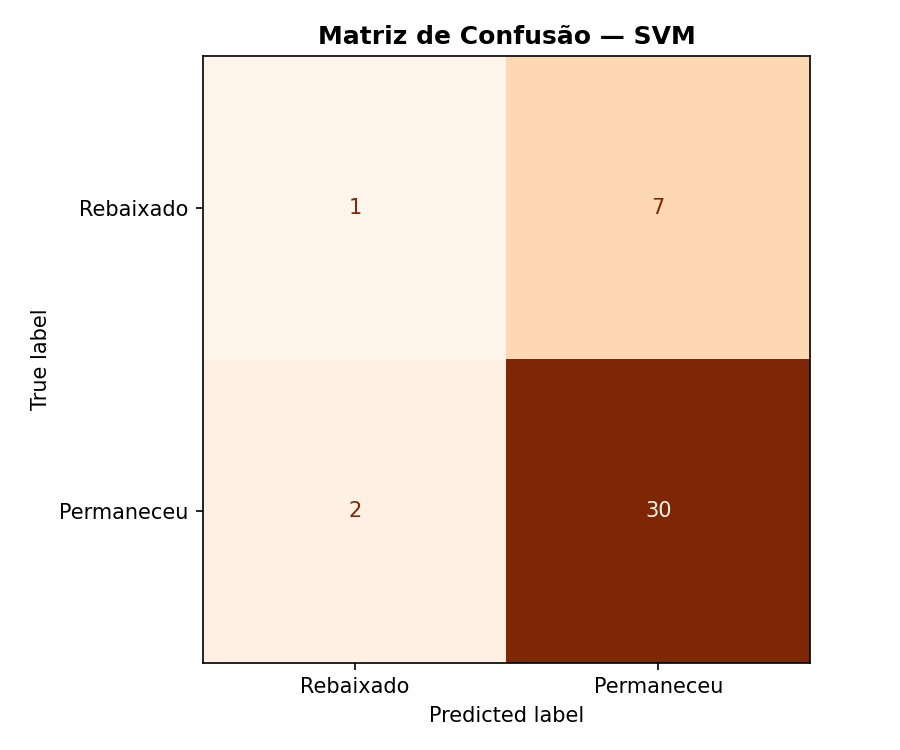

In [3]:
y_pred = svm.predict(X_te)
acc = accuracy_score(y_te, y_pred)
print(f'Acurácia no teste: {acc:.4f} ({acc*100:.2f}%)')
print()
print('Relatório de Classificação:')
print(classification_report(y_te, y_pred, target_names=['Rebaixado', 'Permaneceu']))
display(Image(filename=os.path.join('..', 'img', 'cm_svm.png')))

## Curva ROC e AUC

AUC: 0.6836


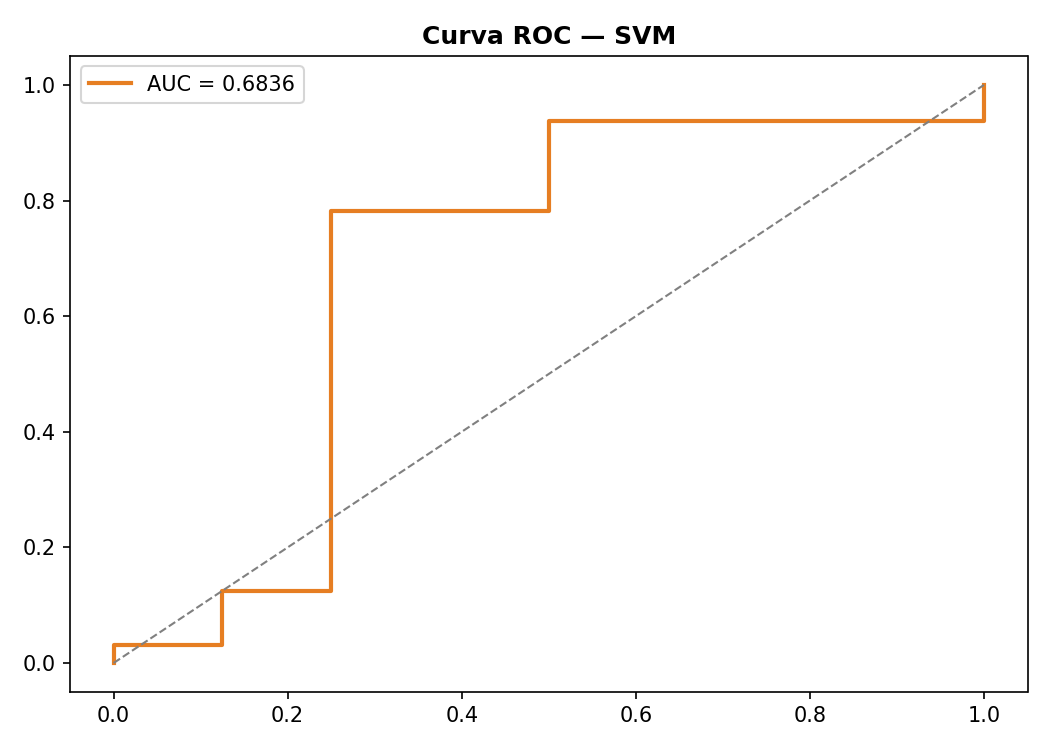

In [4]:
y_prob = svm.predict_proba(X_te)[:, 1]
fpr, tpr, _ = roc_curve(y_te, y_prob)
roc_auc = auc(fpr, tpr)
print(f'AUC: {roc_auc:.4f}')
display(Image(filename=os.path.join('..', 'img', 'roc_svm.png')))

## Probabilidades por Clube no Conjunto de Teste

In [5]:
probs = svm.predict_proba(X_te)
idx_reb = list(svm.classes_).index(0)

df_res = df_te[['Clube', 'Temporada']].copy()
df_res['Prob_Rebaixamento(%)'] = (probs[:, idx_reb] * 100).round(2)
df_res['Real']     = y_te
df_res['Previsto'] = svm.predict(X_te)
df_res = df_res.sort_values('Prob_Rebaixamento(%)', ascending=False)

print('Probabilidades de rebaixamento (conjunto de teste):')
df_res

Probabilidades de rebaixamento (conjunto de teste):


,Clube,Temporada,Prob_Rebaixamento(%),Real,Previsto
124,Juventude,2024,42.70,1,0
61,Vitória,2024,35.17,1,0
31,Goiás,2023,34.47,0,0
110,América Mineiro,2023,17.96,0,1
96,Atlético Goianiense,2024,15.88,0,1
51,Coritiba,2023,14.78,0,1
190,Cuiabá,2023,14.56,1,1
3,Bahia,2023,14.24,1,1
150,Cruzeiro,2023,14.21,1,1
9,Flamengo,2024,13.41,1,1


## Salvando o Modelo

In [6]:
print('Modelo: modelos/svm.pkl')
print('Scaler: modelos/scaler_svm.pkl')
print('Imagens salvas em img/')
print('Status: OK — treinado via terminal Python')

Modelo: modelos/svm.pkl
Scaler: modelos/scaler_svm.pkl
Imagens salvas em img/
Status: OK — treinado via terminal Python


## Interpretação e Comparação

Descreva os resultados obtidos pelo SVM e compare com os modelos anteriores.

**Pontos a observar:**
- O SVM com kernel RBF pode capturar fronteiras de decisão não-lineares, o que pode ser uma vantagem sobre a Regressão Logística.
- Por não fornecer coeficientes diretos, a interpretabilidade é menor do que a Regressão Logística.
- O número de vetores de suporte indica a complexidade da fronteira aprendida: muitos vetores podem indicar overfitting.
- Com dados normalizados (StandardScaler), o SVM tende a ter desempenho mais estável.
- Compare AUC, precision e recall para a classe minoritária (Rebaixado) entre os três modelos treinados.